In [38]:
## Import Tools

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import random

In [63]:
## Loading Dataset from Excel file and exploring Data
data = pd.read_csv("Contributions2025.csv")
data.shape

/var/folders/d4/60vnqbrn48x8vznwxpq7b6h80000gn/T/ipykernel_86013/2782571390.py:2: DtypeWarning: Columns (0: EXEMPTCD) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Contributions2025.csv")


(259967, 52)

In [64]:
## Will Provide the First 5 Rows of Data
data.head()

,ELECTION,OFFICECD,RECIPID,CANCLASS,RECIPNAME,COMMITTEE,FILING,SCHEDULE,PAGENO,SEQUENCENO,...,INTEMPSTNM,INTEMPCITY,INTEMPST,INTOCCUPA,PURPOSECD,EXEMPTCD,ADJTYPECD,RR_IND,SEG_IND,INT_C_CODE
0,2025,2,1682,P,"Rajkumar, Jenifer",I,7,ABC,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,N,NaN
1,2025,IS,Z202,NaN,United New Yorkers for Progress,NaN,20,ICONT,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,5,2436,P,"Caban, Tiffany",K,9,ABC,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,N,NaN
3,2025,5,1683,P,"Banks, Christopher",K,9,ABC,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,N,NaN
4,2025,5,2343,P,"Ung, Sandra",K,11,ABC,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,N,NaN


In [42]:
## Define all the columns in the dataset. This will be cross-referenced manually with the Key Provided in order to decipher what each column name represents

data.columns

Index(['ELECTION', 'OFFICECD', 'RECIPID', 'CANCLASS', 'RECIPNAME', 'COMMITTEE',
       'FILING', 'SCHEDULE', 'PAGENO', 'SEQUENCENO', 'REFNO', 'DATE',
       'REFUNDDATE', 'NAME', 'C_CODE', 'STRNO', 'STRNAME', 'APARTMENT',
       'BOROUGHCD', 'CITY', 'STATE', 'ZIP', 'OCCUPATION', 'EMPNAME',
       'EMPSTRNO', 'EMPSTRNAME', 'EMPCITY', 'EMPSTATE', 'AMNT', 'MATCHAMNT',
       'PREVAMNT', 'PAY_METHOD', 'INTERMNO', 'INTERMNAME', 'INTSTRNO',
       'INTSTRNM', 'INTAPTNO', 'INTCITY', 'INTST', 'INTZIP', 'INTEMPNAME',
       'INTEMPSTNO', 'INTEMPSTNM', 'INTEMPCITY', 'INTEMPST', 'INTOCCUPA',
       'PURPOSECD', 'EXEMPTCD', 'ADJTYPECD', 'RR_IND', 'SEG_IND',
       'INT_C_CODE'],
      dtype='str')

In [44]:
## Renaming Column Names and Selecting the information i will work with for sake of clarity and narrowing the dataset down

DONOR_NAME = "NAME"
DONOR_ZIP = "ZIP"
BOROUGH = "BOROUGHCD"
CANDIDATE = "RECIPNAME"
AMOUNT = "AMNT"
DONOR_TYPE = "C_CODE"

In [45]:
## K = Brooklyn, M = Manhattan, Q = Queens, S = Staten Island, X = Bronx, Z = Outside New York City 

print(data[BOROUGH].value_counts())

BOROUGHCD
K    72077
M    68157
Z    57315
Q    36858
X    14663
S     8833
Name: count, dtype: int64


In [46]:
## CAN = Candidate, CORP = Corporation, EMPO = Labor Union; FAM = Candidate's Family; IND = Individual; LLC = Limited Liability Company; OTHR = Other; PART = Partnership; PCOMC = Candidate Committee; PCOMP = Political Action Committee; PCOMZ = Party Committee; SPO = Candidate's Spouse; UNKN = Unknown

print(data[DONOR_TYPE].value_counts())

C_CODE
IND      257204
PCOMP      1319
CAN         372
FAM         207
EMPO        189
CORP        175
OTHR        172
LLC         131
PCOMC        96
PCOMZ        50
SPO          42
PART         10
Name: count, dtype: int64


In [47]:
## Cleaning The Data
print("Starting rows:", len(data))
## Removing Contributions that are refunds, these can be potential outlier and are not relevant to our data
df = data[data[AMOUNT] > 0].copy()
print("After dropping refunds:", len(df))
# We are going to focus our work on Individuals and remove any companies or unions, those relationships are harder to define as they are groups and not individuals
df = df[df[DONOR_TYPE] == "IND"]
print("After keeping individuals:", len(df))

# We also want to focus our analysis to the 5 boroughs so we remove Z and convert the codes to readable names within a list. 
borough_names = {"M": "Manhattan", "K": "Brooklyn", "Q": "Queens",
                 "X": "Bronx", "S": "Staten Island"}
df["borough"] = df[BOROUGH].map(borough_names)
df = df.dropna(subset=["borough"])
print("After keeping the 5 boroughs:", len(df))

# 1 ID per person to remove any duplicates or individuals with the same name, we pair the name with a ZIP. 
df["donor_id"] = df[DONOR_NAME].astype(str).str.upper().str.strip() + " | " + df[DONOR_ZIP].astype(str).str[:5]
df["candidate"] = df[CANDIDATE].astype(str).str.strip()

print("Unique donors:", df["donor_id"].nunique())
print("Unique candidates:", df["candidate"].nunique())

Starting rows: 259967
After dropping refunds: 256172
After keeping individuals: 253561
After keeping the 5 boroughs: 196050
Unique donors: 115698
Unique candidates: 243


In [65]:
## Building the Network 
## This Creates the Relationship between Donor and Candidate and what borough they are from. Every degree consiiders their donation to who and not the frequency of the donation. 


edges = df[["donor_id", "candidate", "borough"]].drop_duplicates(subset=["donor_id", "candidate"])
donor_borough = edges.groupby("donor_id")["borough"].first()

#Create and Fill the Network
G=nx.Graph()
G.add_nodes_from(edges["candidate"].unique(), kind="candidate")
G.add_nodes_from(donor_borough.index, kind="donor")
nx.set_node_attributes(G, donor_borough.to_dict(), "borough")
G.add_edges_from(zip(edges["donor_id"], edges["candidate"]))

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 115941
Edges: 144472


In [49]:
## Degree Centrality 
## Couting the number of lines connected to each mode, this will represent how many people donated to that candidate and for the donor it will represent how many candidates did they donate to. 

## From the results we can see that Mamdani has the most amount of donors and there is a striking difference in the amount of donors from the 1st to the 2nd candidate, almost 3 times more donors. 
degree = dict(G.degree())

candidates = [n for n, d in G.nodes(data=True) if d["kind"] == "candidate"]
donors     = [n for n, d in G.nodes(data=True) if d["kind"] == "donor"]

cand_table = pd.DataFrame({"candidate": candidates,
                           "donors": [degree[c] for c in candidates]})
cand_table.sort_values("donors", ascending=False).head(10)

,candidate,donors
18,"Mamdani, Zohran K",24669
27,"Lander, Brad",7593
39,"Sliwa, Curtis A",7592
13,"Cuomo, Andrew M",7131
34,"Stringer, Scott M",4608
11,"Adams, Adrienne E",4469
24,"Myrie, Zellnor",4273
25,"Levine, Mark",4089
42,"Adams, Eric L",4074
56,"Brannan, Justin",3363


In [50]:
## Eigenvector Centrality 
## How important are each nodes connections. A donor who donates to a candidate who has more donors scores higher in the Eigenvector centrality

largest = max(nx.connected_components(G), key=len)
H = G.subgraph(largest)
print("Nodes in largest piece:", H.number_of_nodes(), "of", G.number_of_nodes())

## Calculates the Eigenvector score for every node in the subgraph H
eigen = nx.eigenvector_centrality_numpy(H)

Nodes in largest piece: 115759 of 115941


In [51]:
## Borough table

donor_table = pd.DataFrame({"donor_id": [d for d in donors if d in eigen]})
donor_table["borough"]     = donor_table["donor_id"].map(nx.get_node_attributes(G, "borough"))
donor_table["degree"]      = donor_table["donor_id"].map(degree)
donor_table["eigenvector"] = donor_table["donor_id"].map(eigen)

borough_table = donor_table.groupby("borough").agg(
    donors=("donor_id", "count"),
    avg_degree=("degree", "mean"),
    avg_eigenvector=("eigenvector", "mean"),
)
borough_table

,donors,avg_degree,avg_eigenvector
borough,,,
Bronx,9431,1.198282,0.000390
Brooklyn,40445,1.253999,0.001396
Manhattan,36675,1.294778,0.000887
Queens,23452,1.204588,0.000922
Staten Island,5535,1.184643,0.000215


In [52]:
## Mamdani vs. Cuomo
## The 2 big contenders in the mayoral election was mamdani and Cuomo so we want to see what comparisons we can draw from the donor relationships. We find here the amount of donors from each borough for both candidates.  

mamdani = [c for c in candidates if "MAMDANI" in c.upper()][0]
cuomo   = [c for c in candidates if "CUOMO" in c.upper()][0]

borough_of = nx.get_node_attributes(G, "borough")
mamdani_donors = list(G.neighbors(mamdani))
cuomo_donors   = list(G.neighbors(cuomo))

pd.DataFrame({
    "Mamdani": pd.Series([borough_of[d] for d in mamdani_donors]).value_counts(),
    "Cuomo":   pd.Series([borough_of[d] for d in cuomo_donors]).value_counts(),
})

,Mamdani,Cuomo
Bronx,787,271
Brooklyn,12079,1302
Manhattan,6860,4504
Queens,4695,873
Staten Island,248,181


In [53]:
## Creating the Netowrk Graphs

random.seed(42)
## Creating a smaller network with 150 sampled donors at random
sample = random.sample(mamdani_donors, 75) + random.sample(cuomo_donors, 75)
S = G.subgraph([mamdani, cuomo] + sample)

colors = {"Manhattan": "#4C72B0", "Brooklyn": "#DD8452", "Queens": "#55A868",
          "Bronx": "#C44E52", "Staten Island": "#8172B3"}
node_colors = ["black" if S.nodes[n]["kind"] == "candidate" else colors[S.nodes[n]["borough"]]
               for n in S.nodes]

pos = nx.spring_layout(S, seed=42)
label_pos = {n: (x, y + 0.12) for n, (x, y) in pos.items()}
legend = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=9, label=b)
          for b, c in colors.items()]

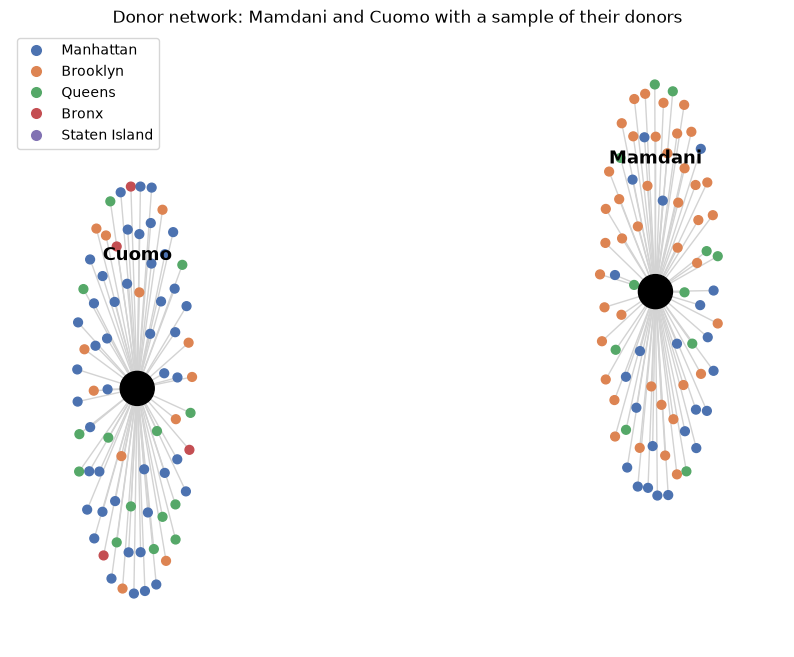

In [59]:
## Graph #1 : Plain Graph A visual of what the total network looks like with subset. All nodes are the same size.

plain_sizes = [600 if S.nodes[n]["kind"] == "candidate" else 40 for n in S.nodes]

plt.figure(figsize=(10, 8))
nx.draw_networkx(S, pos, node_color=node_colors, node_size=plain_sizes, with_labels=False, edge_color="lightgray")
nx.draw_networkx_labels(S, label_pos, labels={mamdani: "Mamdani", cuomo: "Cuomo"}, font_size=13, font_weight="bold")
plt.legend(handles=legend, loc="upper left")
plt.title("Donor network: Mamdani and Cuomo with a sample of their donors")
plt.axis("off")
plt.show()

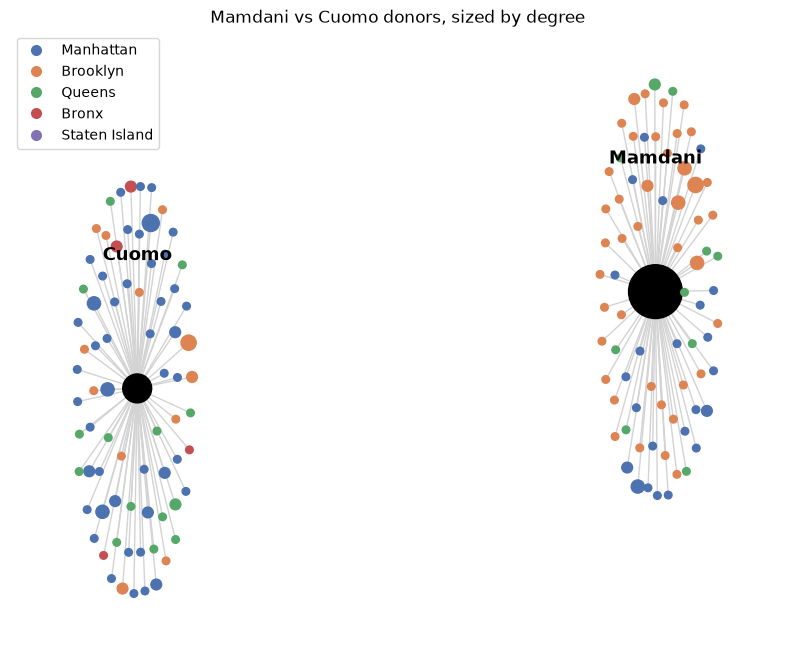

In [55]:
## Graph #2 - Sized by Degree, Larger Nodes represent donors who gave to more candidates. 

sizes = [1500 * degree[n] / degree[mamdani] if S.nodes[n]["kind"] == "candidate" else 30 * degree[n]
         for n in S.nodes]

plt.figure(figsize=(10, 8))
nx.draw_networkx(S, pos, node_color=node_colors, node_size=sizes, with_labels=False, edge_color="lightgray")
nx.draw_networkx_labels(S, label_pos, labels={mamdani: "Mamdani", cuomo: "Cuomo"}, font_size=13, font_weight="bold")
plt.legend(handles=legend, loc="upper left")
plt.title("Mamdani vs Cuomo donors, sized by degree")
plt.axis("off")
plt.show()

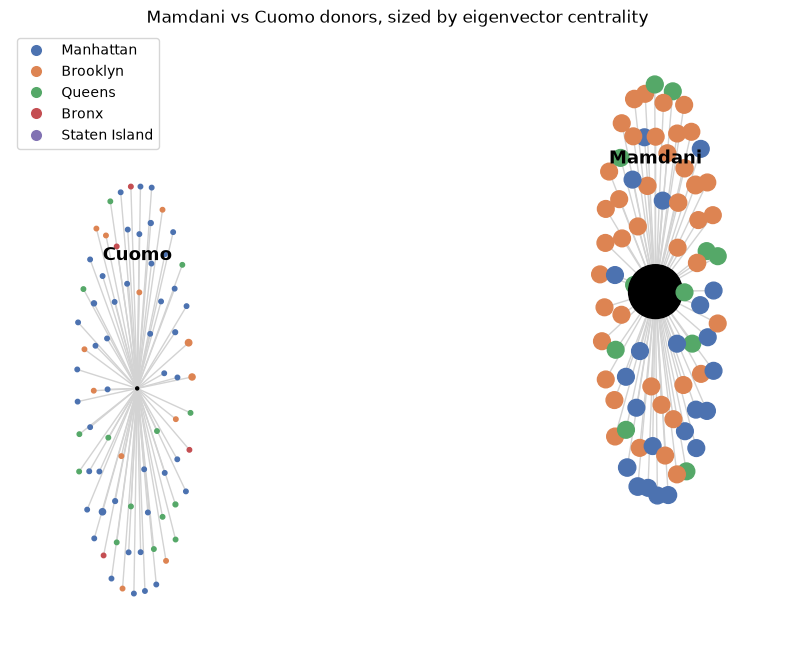

In [58]:
## Graph #3 - Sized By Eigenvector, Donors who backed the biggest candidates get bigger dots

max_donor = max(eigen[n] for n in sample)
sizes = [1500 * eigen[n] / eigen[mamdani] if S.nodes[n]["kind"] == "candidate"
         else 10 + 150 * eigen[n] / max_donor
         for n in S.nodes]

plt.figure(figsize=(10, 8))
nx.draw_networkx(S, pos, node_color=node_colors, node_size=sizes, with_labels=False, edge_color="lightgray")
nx.draw_networkx_labels(S, label_pos, labels={mamdani: "Mamdani", cuomo: "Cuomo"}, font_size=13, font_weight="bold")
plt.legend(handles=legend, loc="upper left")
plt.title("Mamdani vs Cuomo donors, sized by eigenvector centrality")
plt.axis("off")
plt.show()

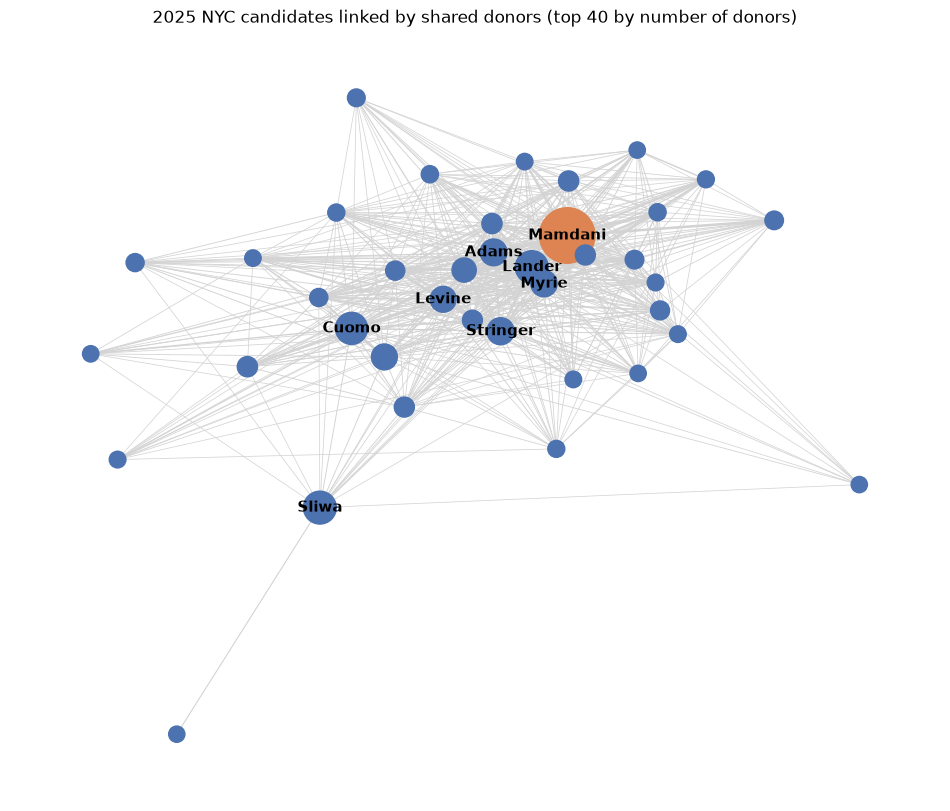

In [60]:
## Graph #4 - Candidate Network (All Candidates) 
## Top 40 Candidates only
## Each edge represents the relationship between candidates and shared donors. 2 candidates that are connected have a shared donor. 

from networkx.algorithms import bipartite

C = bipartite.weighted_projected_graph(G, candidates)

top = sorted(candidates, key=lambda c: degree[c], reverse=True)[:40]
C_top = C.subgraph(top)

min_shared = 5
C_show = nx.Graph()
C_show.add_nodes_from(top)
C_show.add_edges_from((u, v, d) for u, v, d in C_top.edges(data=True) if d["weight"] >= min_shared)
C_show.remove_nodes_from(list(nx.isolates(C_show)))

pos_c = nx.spring_layout(C_show, seed=42, k=1.0)
sizes_c = [100 + 1500 * degree[c] / degree[mamdani] for c in C_show.nodes]
max_w = max(w for _, _, w in C_show.edges(data="weight"))
widths = [0.5 + 4 * d["weight"] / max_w for _, _, d in C_show.edges(data=True)]
colors_c = ["#DD8452" if c == mamdani else "#4C72B0" for c in C_show.nodes]
labels_c = {c: c.split(",")[0] for c in top[:8] if c in C_show}

plt.figure(figsize=(12, 10))
nx.draw_networkx_edges(C_show, pos_c, width=widths, edge_color="lightgray")
nx.draw_networkx_nodes(C_show, pos_c, node_size=sizes_c, node_color=colors_c)
nx.draw_networkx_labels(C_show, pos_c, labels=labels_c, font_size=11, font_weight="bold")
plt.title("2025 NYC candidates linked by shared donors (top 40 by number of donors)")
plt.axis("off")
plt.show()

In [ ]:
## Conluding Remarks 

## Question #1 - Which Candidate had the most donors?
## Zohran Mamdani had the most donors with a whopping 24,669. He had more than 3 times the amount of donors that any other candidate. By degree he is the most central candidate beacuse of the sheer quanity of donor relations.

## Question #2 - Where do Mamdani's donors live compared to Cuomo?
## Aside from the difference in the total amount of donors we can see a differnce in where those donors come from for each candidate. Mamdani has donors concentrated in brooklyn (49%) and followed by Manhattan (28%). Cuomo had a concentraion of donors in Manhattan(63%) and Brooklyn in second (18%).

## Question #3 - Do Donors in some boroughs give to more candidates? 
## Manhattan Donors had the highest average degree, followed by brooklyn, Staten island and the bronx with the lowest. Most donors in every borough gave to just one candidate, Manhattan had the highest because the money was probably spread to different campaigns. 

## Question #4 - Do Donotrs in some boroughs back the biggest candidates more?
## Brooklyn donors had the highest eigen score at 0.0014 ahead of Queens and Manhattan at 0.0009. This number is increased by giving to the biggest campaign, and remember that Brooklyn is where most of mandani's donors come from. Manhattan give to the most candidates and Brooklyn donors give to the most important or central candidates. 